# 0. Connect Google Drive

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Import Libraries

In [11]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.backend import clear_session

# 2. Load Split Dataset

In [12]:
import sys

project_dir = "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification"
sys.path.append(project_dir)

from utils import load_animals10_datasets

train_dataset, val_dataset, test_dataset, class_names = load_animals10_datasets()

Using Colab cache for faster access to the 'animals10' dataset.


### Check Data

In [13]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

print(class_names)

(32, 128, 128, 3)
(32, 10)
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


# 3. Define Model

In [14]:
from keras.backend import clear_session
clear_session()

## 3.1 Phase 1 Load MobileNetV2 and Freeze Base Model

In [15]:
from tensorflow.keras.applications import MobileNetV2

num_classes = 10
input_shape= (128, 128, 3)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=input_shape
)

base_model.trainable = False

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Rescaling(2.0, offset=-1),

        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 4. Compile and Train Model

In [16]:
import time
from keras.optimizers import Adam

epochs = 30
my_opt1 = Adam(learning_rate=0.0001)
my_opt2 = Adam(learning_rate=0.00001)

model.compile(
    loss="categorical_crossentropy",
    optimizer=my_opt1,
    metrics=['accuracy']
)

early_stop1 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Track train time: starting timing
start_time = time.time()

history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stop1]
)

# Track train time: end timing
end_time = time.time()

phase1_time = end_time - start_time

print(f"Phase 1 training time: {phase1_time:.2f} seconds")
print(f"Phase 1 training time: {phase1_time / 60:.2f} minutes")

Epoch 1/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 96s 132ms/step - accuracy: 0.8029 - loss: 0.6605 - val_accuracy: 0.9301 - val_loss: 0.2306
Epoch 2/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.9241 - loss: 0.2521 - val_accuracy: 0.9385 - val_loss: 0.1984
Epoch 3/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.9376 - loss: 0.2012 - val_accuracy: 0.9442 - val_loss: 0.1798
Epoch 4/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.9468 - loss: 0.1736 - val_accuracy: 0.9450 - val_loss: 0.1754
Epoch 5/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.9519 - loss: 0.1526 - val_accuracy: 0.9488 - val_loss: 0.1726
Epoch 6/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.9555 - loss: 0.1393 - val_accuracy: 0.9484 - val_loss: 0.1693
Epoch 7/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.9633 - loss: 0.1199 - val_accuracy: 0.9481 - val_loss: 0.1651
Epoch 8/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.9662 - loss: 0.1075 -

## 5. Evaluate Phase 1

In [17]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Phase 1 Test loss:", test_loss)
print("Phase 1 Test accuracy:", test_accuracy)

82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.9477 - loss: 0.1768
Phase 1 Test loss: 0.1768309623003006
Phase 1 Test accuracy: 0.9476699829101562


# 6. Phase 2 Unfreeze and Fine-tune

In [18]:
base_model.trainable = True

for layer in base_model.layers[:90]:
    layer.trainable = False
for layer in base_model.layers[90:]:
    layer.trainable = True

trainable_count = sum([layer.trainable for layer in base_model.layers])
print("Trainable layers in base_model:", trainable_count)
print("Total layers in base_model:", len(base_model.layers))

Trainable layers in base_model: 64
Total layers in base_model: 154


# 7. Re-compile With Very Small Learning Rate

In [19]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=my_opt2,
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Track train time: starting timing
start_time = time.time()

history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stop2]
)

# Track train time: end timing
end_time = time.time()

phase2_time = end_time - start_time

print(f"Phase 2 training time: {phase2_time:.2f} seconds")
print(f"Phase 2 training time: {phase2_time / 60:.2f} minutes")

Epoch 1/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 73s 72ms/step - accuracy: 0.9110 - loss: 0.2679 - val_accuracy: 0.9503 - val_loss: 0.1734
Epoch 2/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.9409 - loss: 0.1812 - val_accuracy: 0.9534 - val_loss: 0.1672
Epoch 3/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.9520 - loss: 0.1486 - val_accuracy: 0.9515 - val_loss: 0.1730
Epoch 4/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.9614 - loss: 0.1191 - val_accuracy: 0.9503 - val_loss: 0.1676
Epoch 5/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.9662 - loss: 0.1016 - val_accuracy: 0.9507 - val_loss: 0.1664
Epoch 6/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9726 - loss: 0.0847 - val_accuracy: 0.9519 - val_loss: 0.1673
Epoch 7/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9759 - loss: 0.0747 - val_accuracy: 0.9496 - val_loss: 0.1692
Epoch 8/30
655/655 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.9791 - loss: 0.0638 - 

# 8. Evaluate Model

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    true_labels = np.argmax(labels.numpy(), axis=1)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(true_labels)
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"Test accuracy: {accuracy}")
print(f"Test precision: {precision}")
print(f"Test recall: {recall}")
print(f"Confusion Matrix: \n {cm}")

Test accuracy: 0.9488158899923606
Test precision: 0.9454821444000627
Test recall: 0.9413502326882481
Confusion Matrix: 
 [[463   6   3   0   3   6   4   0   0   2]
 [  8 242   0   0   2   0   6   4   0   0]
 [  0   0 140   0   0   0   0   2   1   2]
 [  2   1   1 198   1   0   0   1   6   1]
 [  2   1   0   0 303   0   0   0   2   2]
 [  8   0   0   0   0 154   0   1   1   3]
 [  7   9   1   0   2   1 158   7   1   0]
 [  3   2   1   0   1   0   4 171   0   0]
 [  0   0   0   4   1   0   0   0 477   0]
 [  0   1   0   0   1   5   0   0   1 178]]


# 9.Plot Loss and Accuracy

In [21]:
history_phase2.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

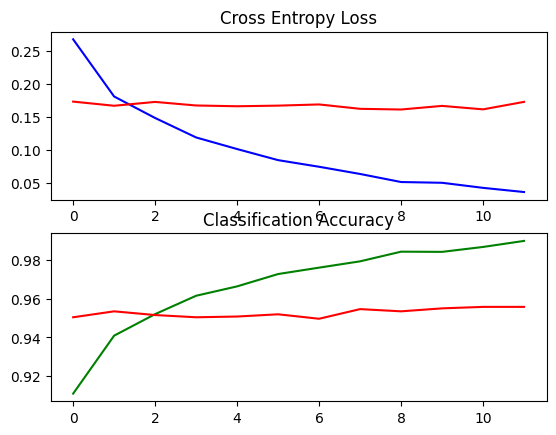

In [22]:
import matplotlib.pyplot as plt

plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history_phase2.history['loss'], color='blue', label='train')
plt.plot(history_phase2.history['val_loss'], color='red', label='validation')

plt.subplot(212)
plt.title('Classification Accuracy')
plt.plot(history_phase2.history['accuracy'], color='green', label='train')
plt.plot(history_phase2.history['val_accuracy'], color='red', label='validation')
plt.show()

# 9.2 Plot Comfusion Matrix

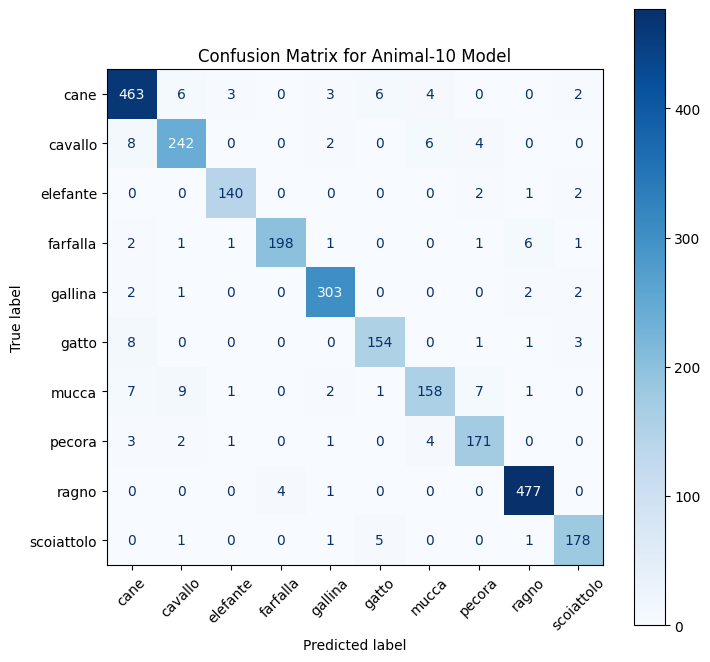

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix for Animal-10 Model")
plt.show()

# 10. Save Model

In [24]:
model.save("/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_8_transfer_finetuning.keras")

print("Model Saved")

Model Saved


In [25]:
# how to import model when needed

'''
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_8_transfer_finetuning.keras"
)
'''

'\nimport tensorflow as tf\n\nmodel = tf.keras.models.load_model(\n    "/content/drive/MyDrive/Colab Notebooks/w3_group-6-cnn-image-classification/saved_models/model_8_transfer_finetuning.keras"\n)\n'